# Определение стоимости автомобилей

Сервис по продаже автомобилей с пробегом «Не бит, не крашен» разрабатывает приложение для привлечения новых клиентов. В нём можно быстро узнать рыночную стоимость своего автомобиля. В вашем распоряжении исторические данные: технические характеристики, комплектации и цены автомобилей. Вам нужно построить модель для определения стоимости. 

Заказчику важны:

- качество предсказания;
- скорость предсказания;
- время обучения.

## Подготовка данных

### Импорт библиотек

In [1]:
!pip install missingno

Defaulting to user installation because normal site-packages is not writeable


In [2]:
import pandas as pd 
import numpy as np 
import optuna
from phik import phik_matrix
from phik.report import plot_correlation_matrix
import missingno as msno
from functools import partial
import time
import seaborn as sns
import matplotlib.pyplot as plt 
from catboost import CatBoostRegressor
from lightgbm import LGBMRegressor
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.base import clone
from sklearn.model_selection import (
    train_test_split,
    cross_validate
)
from sklearn.preprocessing import (
    OneHotEncoder,
    OrdinalEncoder,
    StandardScaler
)
from sklearn.base import TransformerMixin, BaseEstimator
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    root_mean_squared_error,
    mean_absolute_error,
    r2_score
)
from optuna import distributions
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [3]:
try:
    data = pd.read_csv('./autos.csv')
except:
    data = pd.read_csv('/datasets/autos.csv')

Вывод первых строк и размера датасета датасета

In [4]:
display(data.head())
print(data.shape)

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
0,2016-03-24 11:52:17,480,NaN,1993,manual,0,golf,150000,0,petrol,volkswagen,NaN,2016-03-24 00:00:00,0,70435,2016-04-07 03:16:57
1,2016-03-24 10:58:45,18300,coupe,2011,manual,190,NaN,125000,5,gasoline,audi,yes,2016-03-24 00:00:00,0,66954,2016-04-07 01:46:50
2,2016-03-14 12:52:21,9800,suv,2004,auto,163,grand,125000,8,gasoline,jeep,NaN,2016-03-14 00:00:00,0,90480,2016-04-05 12:47:46
3,2016-03-17 16:54:04,1500,small,2001,manual,75,golf,150000,6,petrol,volkswagen,no,2016-03-17 00:00:00,0,91074,2016-03-17 17:40:17
4,2016-03-31 17:25:20,3600,small,2008,manual,69,fabia,90000,7,gasoline,skoda,no,2016-03-31 00:00:00,0,60437,2016-04-06 10:17:21


(354369, 16)


### Описание данных

Признаки
* `DateCrawled` — дата скачивания анкеты из базы
* `VehicleType` — тип автомобильного кузова
* `RegistrationYear` — год регистрации автомобиля
* `Gearbox` — тип коробки передач
* `Power` — мощность (л. с.)
* `Model` — модель автомобиля
* `Kilometer` — пробег (км)
* `RegistrationMonth` — месяц регистрации автомобиля
* `FuelType` — тип топлива
* `Brand` — марка автомобиля
* `Repaired` — была машина в ремонте или нет
* `DateCreated` — дата создания анкеты
* `NumberOfPictures` — количество фотографий автомобиля
* `PostalCode` — почтовый индекс владельца анкеты (пользователя)
* `LastSeen` — дата последней активности пользователя

Целевой признак

`Price` — цена (евро)

### Анализ пропущенных значений

Число пропусков в каждом их столбцов

In [5]:
data.isna().sum()

DateCrawled              0
Price                    0
VehicleType          37490
RegistrationYear         0
Gearbox              19833
Power                    0
Model                19705
Kilometer                0
RegistrationMonth        0
FuelType             32895
Brand                    0
Repaired             71154
DateCreated              0
NumberOfPictures         0
PostalCode               0
LastSeen                 0
dtype: int64

Визуализация пропущенных значений

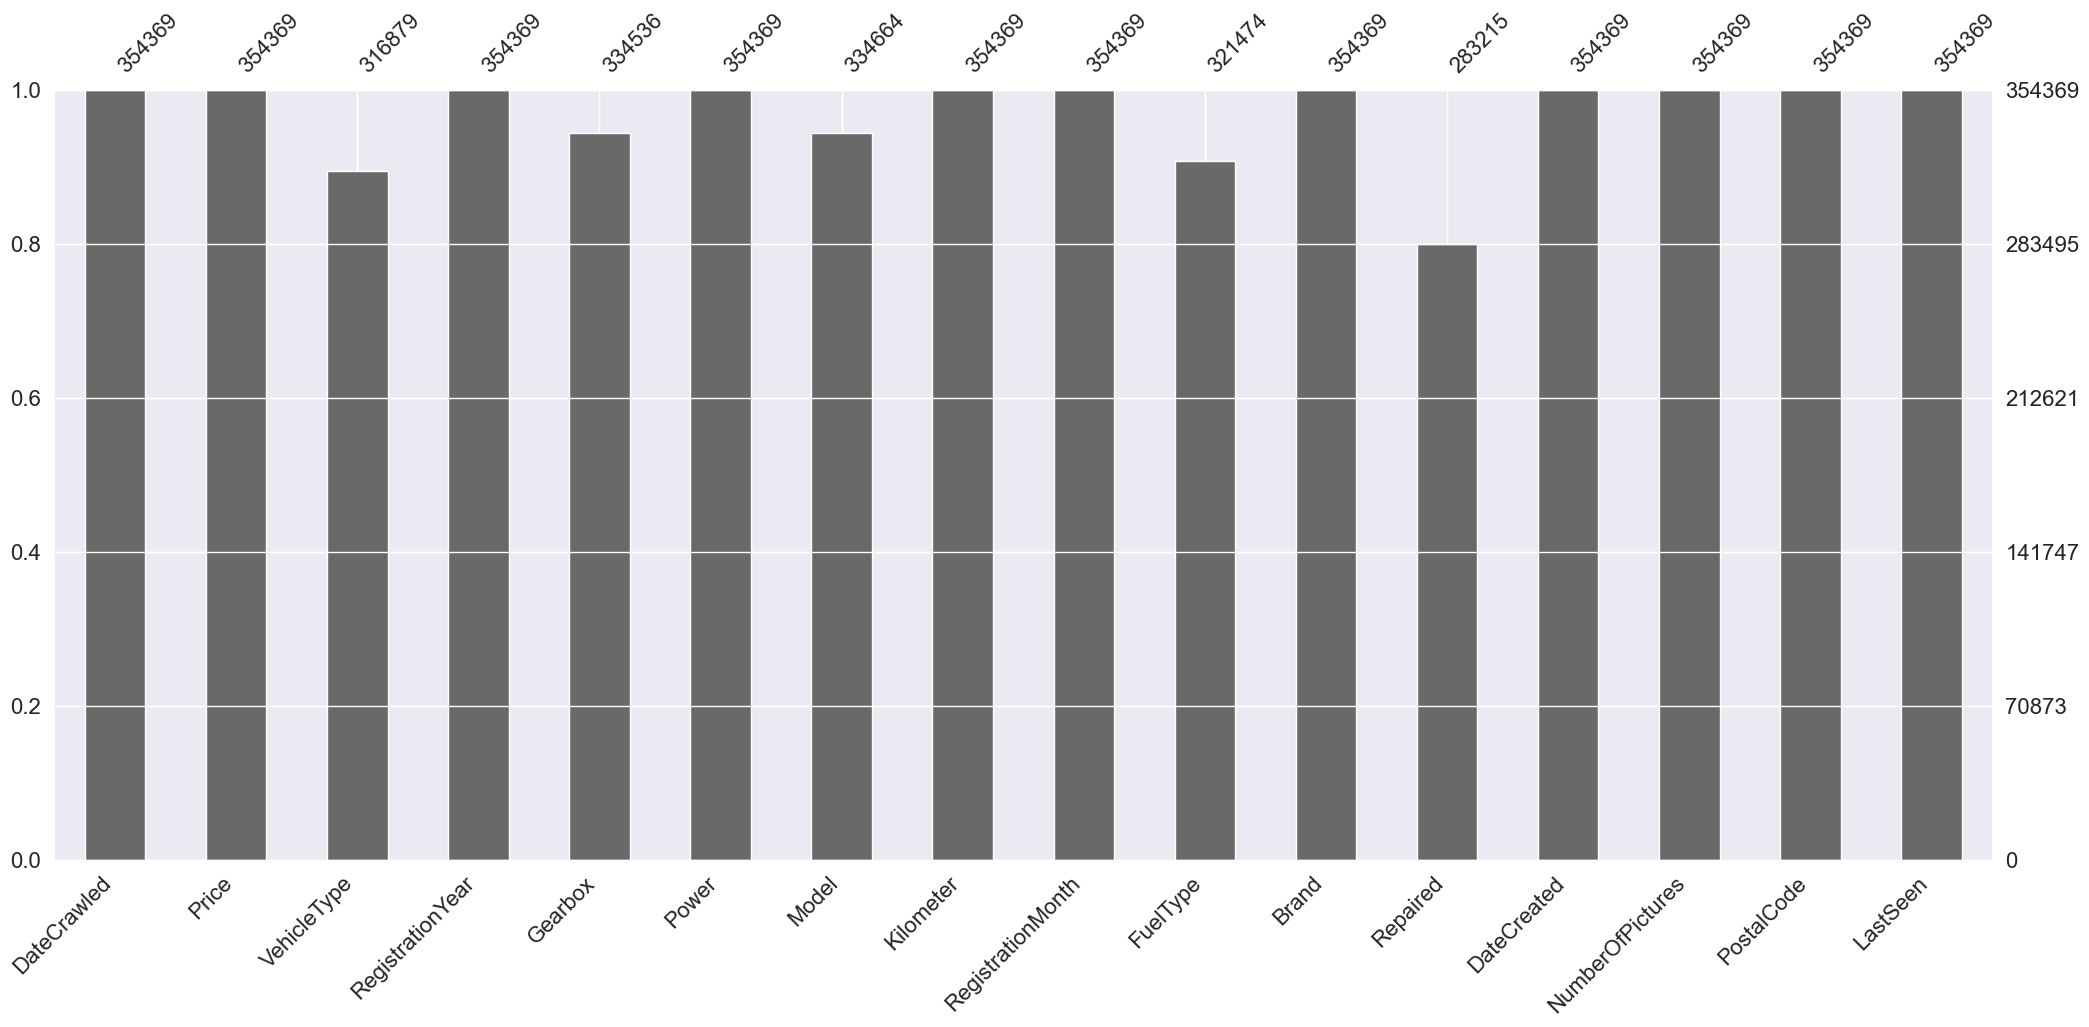

In [6]:
sns.set()
msno.bar(data);

Корреляция пропущенных значений

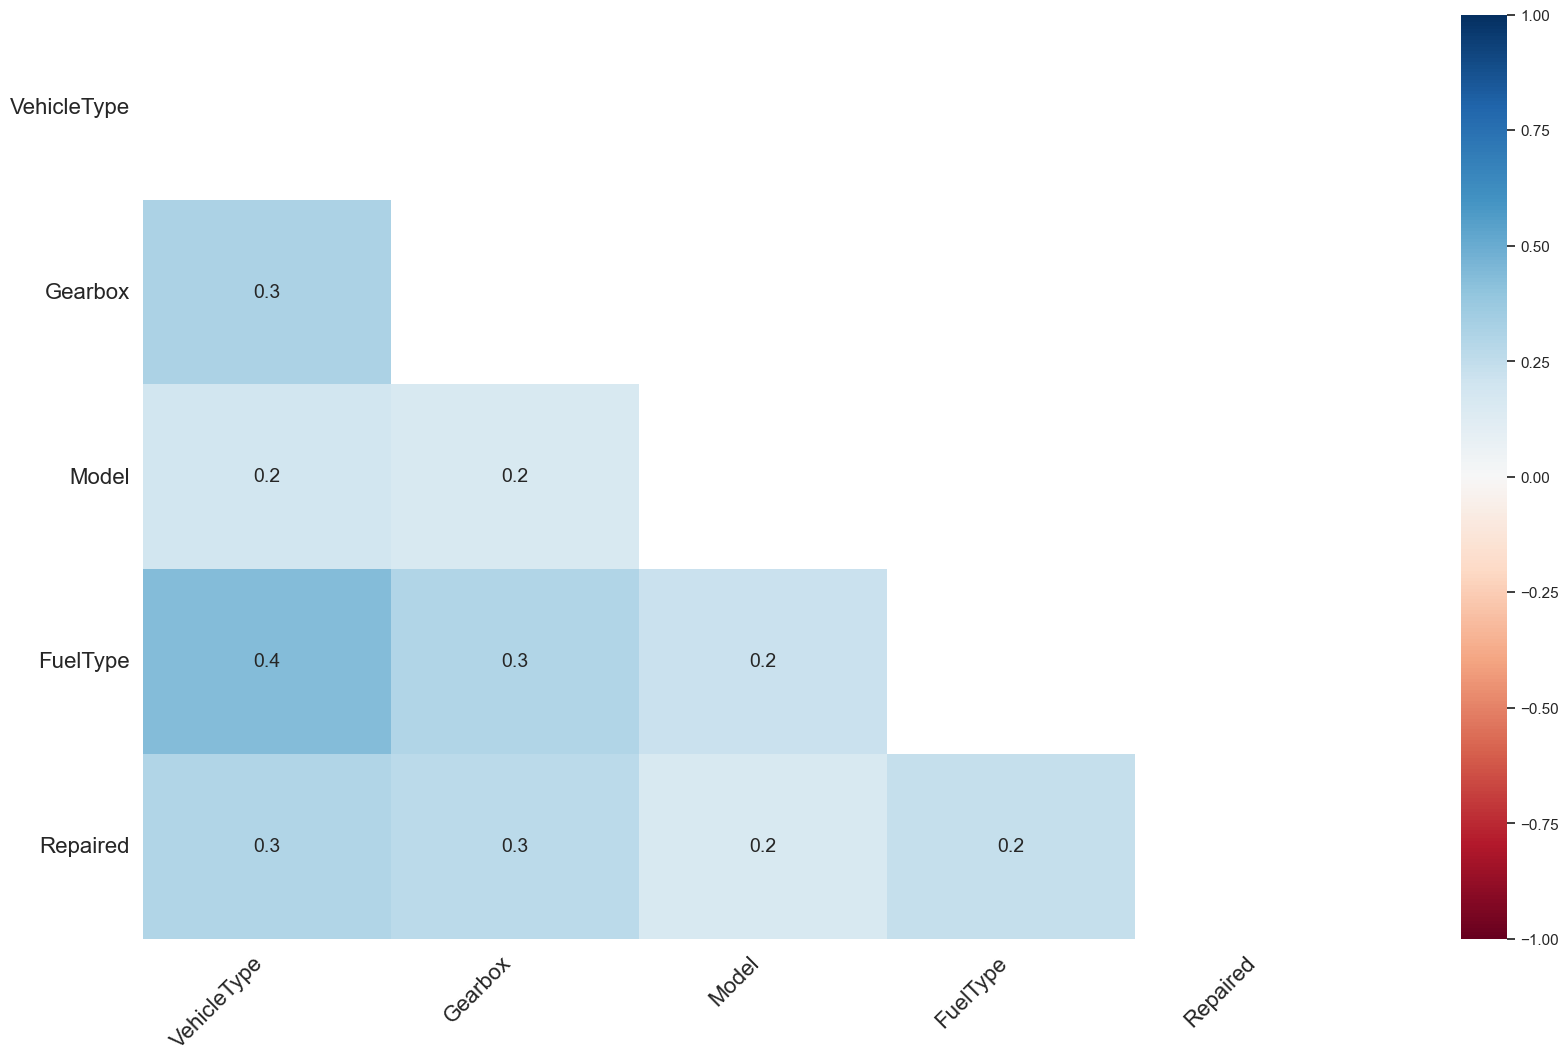

In [7]:
msno.heatmap(data);

Значения слабо скоррелированы

Количество уникальных значений в столбцах с пропусками

In [8]:
data.loc[:, ['VehicleType', 'Gearbox', 'Model', 'FuelType', 'Repaired']].nunique()

VehicleType      8
Gearbox          2
Model          250
FuelType         7
Repaired         2
dtype: int64

Частоты значений и количество пропусков для столбцов с пропусками `VehicleType`, `Gearbox`, `FuelType`, `Repaired`

In [9]:
for column in ['VehicleType', 'Gearbox', 'FuelType', 'Repaired']:
    print(column)
    display(data.loc[:, column].value_counts())
    print('Число пропусков =', data.loc[:, column].isna().sum())
    print()
    print('-----------------------------------------')
    print()

VehicleType


VehicleType
sedan          91457
small          79831
wagon          65166
bus            28775
convertible    20203
coupe          16163
suv            11996
other           3288
Name: count, dtype: int64

Число пропусков = 37490

-----------------------------------------

Gearbox


Gearbox
manual    268251
auto       66285
Name: count, dtype: int64

Число пропусков = 19833

-----------------------------------------

FuelType


FuelType
petrol      216352
gasoline     98720
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64

Число пропусков = 32895

-----------------------------------------

Repaired


Repaired
no     247161
yes     36054
Name: count, dtype: int64

Число пропусков = 71154

-----------------------------------------



Стратегия заполнения пропусков:
* `VehicleType` - не можем определить тип кузова по другим полям; если заполним пропуски самым частым значением, то заметно исказим доли разных кузовов. Заполняем отдельной категорией `unknown`
* `Gearbox` - не можем определить тип коробки передач по другим полям; можем заполнять пропуски как `наиболее встречаемым значением` (число строк с таким значением вырастет менее, чем на 10%), так и отдельной категорией `unknown`. Для простоты заполним `наиболее встречаемым значением`.
* `FuelType` - не можем определить тип топлива по другим полям; можем заполнить пропуски как `наиболее встречаемым значением` (количество пропусков составляем примерно 15% от числа строк с самым частым значением), так и специальным значением `unknown`. Для этого поля выберем вариант с `unknown`.
* `Repaired` - сложно определить причину отсутствия информации о ремонте (потеря данных; отсутствие ремонта как смысл пропуска; отсутствие значения, чтобы не указывать наличие ремонта); если заполним все пропуски одним конкретным значением, то заметно исказим доли значений. Заполняем отдельным значением `unknown`.

5 наиболее встречаемых значений и число пропусков в поле `Model`

In [10]:
display(data['Model'].value_counts().head())
print('Число пропусков =', data['Model'].isna().sum())


Model
golf     29232
other    24421
3er      19761
polo     13066
corsa    12570
Name: count, dtype: int64

Число пропусков = 19705


* `Model` - число пропусков слишком большое в сравнении с количеством объявлений для каждой конкретной модели, так что заполняем пропуски значением `unknown`.

### Заполнение пропущенных значений

In [11]:
data['VehicleType'] = data['VehicleType'].fillna('unknown')
#data['Gearbox'] = data['Gearbox'].fillna(data['Gearbox'].mode()[0])
data['Gearbox'] = data['Gearbox'].fillna('unknown')
data['FuelType'] = data['FuelType'].fillna('unknown')
data['Repaired'] = data['Repaired'].fillna('unknown')
data['Model'] = data['Model'].fillna('unknown') 

Проверка

In [12]:
data.isna().sum()

DateCrawled          0
Price                0
VehicleType          0
RegistrationYear     0
Gearbox              0
Power                0
Model                0
Kilometer            0
RegistrationMonth    0
FuelType             0
Brand                0
Repaired             0
DateCreated          0
NumberOfPictures     0
PostalCode           0
LastSeen             0
dtype: int64

### Анализ дубликатов в данных

In [13]:
data.duplicated().sum()

4

In [14]:
data[data.duplicated(keep=False)]

,DateCrawled,Price,VehicleType,RegistrationYear,Gearbox,Power,Model,Kilometer,RegistrationMonth,FuelType,Brand,Repaired,DateCreated,NumberOfPictures,PostalCode,LastSeen
41529,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18 00:00:00,0,36391,2016-03-18 18:46:15
88087,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08 00:00:00,0,89518,2016-03-09 09:46:57
90964,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28 00:00:00,0,66589,2016-03-28 08:46:21
171088,2016-03-08 18:42:48,1799,coupe,1999,auto,193,clk,20000,7,petrol,mercedes_benz,no,2016-03-08 00:00:00,0,89518,2016-03-09 09:46:57
187735,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03 00:00:00,0,75196,2016-04-07 09:44:54
231258,2016-03-28 00:56:10,1000,small,2002,manual,83,other,150000,1,petrol,suzuki,no,2016-03-28 00:00:00,0,66589,2016-03-28 08:46:21
258109,2016-04-03 09:01:15,4699,coupe,2003,auto,218,clk,125000,6,petrol,mercedes_benz,yes,2016-04-03 00:00:00,0,75196,2016-04-07 09:44:54
325651,2016-03-18 18:46:15,1999,wagon,2001,manual,131,passat,150000,7,gasoline,volkswagen,no,2016-03-18 00:00:00,0,36391,2016-03-18 18:46:15


Нашлось 4 явных дубликата, удалим их

In [15]:
data = data.drop_duplicates()

Проверка

In [16]:
data.duplicated().sum()

0

#### Неявные дупликаты

In [17]:
data['FuelType'].value_counts()

FuelType
petrol      216349
gasoline     98719
unknown      32895
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64

`petrol` и `gasoline` - названия одного и того же топлива в разных странах, так что это неявный дубликат. Назовем все это `petrol`

In [18]:
data['FuelType'] = data['FuelType'].replace('gasoline', 'petrol')

Проверка

In [19]:
data['FuelType'].value_counts()

FuelType
petrol      315068
unknown      32895
lpg           5310
cng            565
hybrid         233
other          204
electric        90
Name: count, dtype: int64

### Проверка правильности типов значений в столбцах

In [20]:
def values_and_type(data):
    dict_to_df = {'column_name': [], 'type': [], 'value_1': [], 'value_2': [], 'value_3': [], 'value_4': [], 'value_5': []}
    for column in data.columns:
        dict_to_df['column_name'].append(column)
        dict_to_df['type'].append(data[column].dtype)
        values = data[column].value_counts().index.to_list()
        for i in range(5):
            if i < len(values):
                dict_to_df['value_' + str(i+1)].append(values[i])
            else:
                dict_to_df['value_' + str(i+1)].append('-')

    new_df = pd.DataFrame(data=dict_to_df)
    display(new_df)

In [21]:
values_and_type(data)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,DateCrawled,object,2016-03-24 14:49:47,2016-03-19 21:49:56,2016-03-26 22:57:31,2016-03-11 15:36:59,2016-03-28 10:36:47
1,Price,int64,0,500,1500,1000,1200
2,VehicleType,object,sedan,small,wagon,unknown,bus
3,RegistrationYear,int64,2000,1999,2005,2001,2006
4,Gearbox,object,manual,auto,unknown,-,-
5,Power,int64,0,75,60,150,101
6,Model,object,golf,other,3er,unknown,polo
7,Kilometer,int64,150000,125000,100000,90000,80000
8,RegistrationMonth,int64,0,3,6,4,5
9,FuelType,object,petrol,unknown,lpg,cng,hybrid


Что необходимо изменить:
* `DateCreated` - теоретически может влиять на цену, но нужно привети к типу даты без времени
* `LastSeen` - нужно привести к типу даты и убрать время

Изменение типов

In [22]:
data['DateCreated'] = pd.to_datetime(data['DateCreated'], format='%Y-%m-%d %H:%M:%S')
data['DateCreated'] = data['DateCreated'].dt.normalize()
data['LastSeen'] = pd.to_datetime(data['LastSeen'], format='%Y-%m-%d %H:%M:%S')
data['LastSeen'] = data['LastSeen'].dt.normalize()

Проверка

In [23]:
values_and_type(data)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,DateCrawled,object,2016-03-24 14:49:47,2016-03-19 21:49:56,2016-03-26 22:57:31,2016-03-11 15:36:59,2016-03-28 10:36:47
1,Price,int64,0,500,1500,1000,1200
2,VehicleType,object,sedan,small,wagon,unknown,bus
3,RegistrationYear,int64,2000,1999,2005,2001,2006
4,Gearbox,object,manual,auto,unknown,-,-
5,Power,int64,0,75,60,150,101
6,Model,object,golf,other,3er,unknown,polo
7,Kilometer,int64,150000,125000,100000,90000,80000
8,RegistrationMonth,int64,0,3,6,4,5
9,FuelType,object,petrol,unknown,lpg,cng,hybrid


### Анализ распределений значений непрерывных столбцов

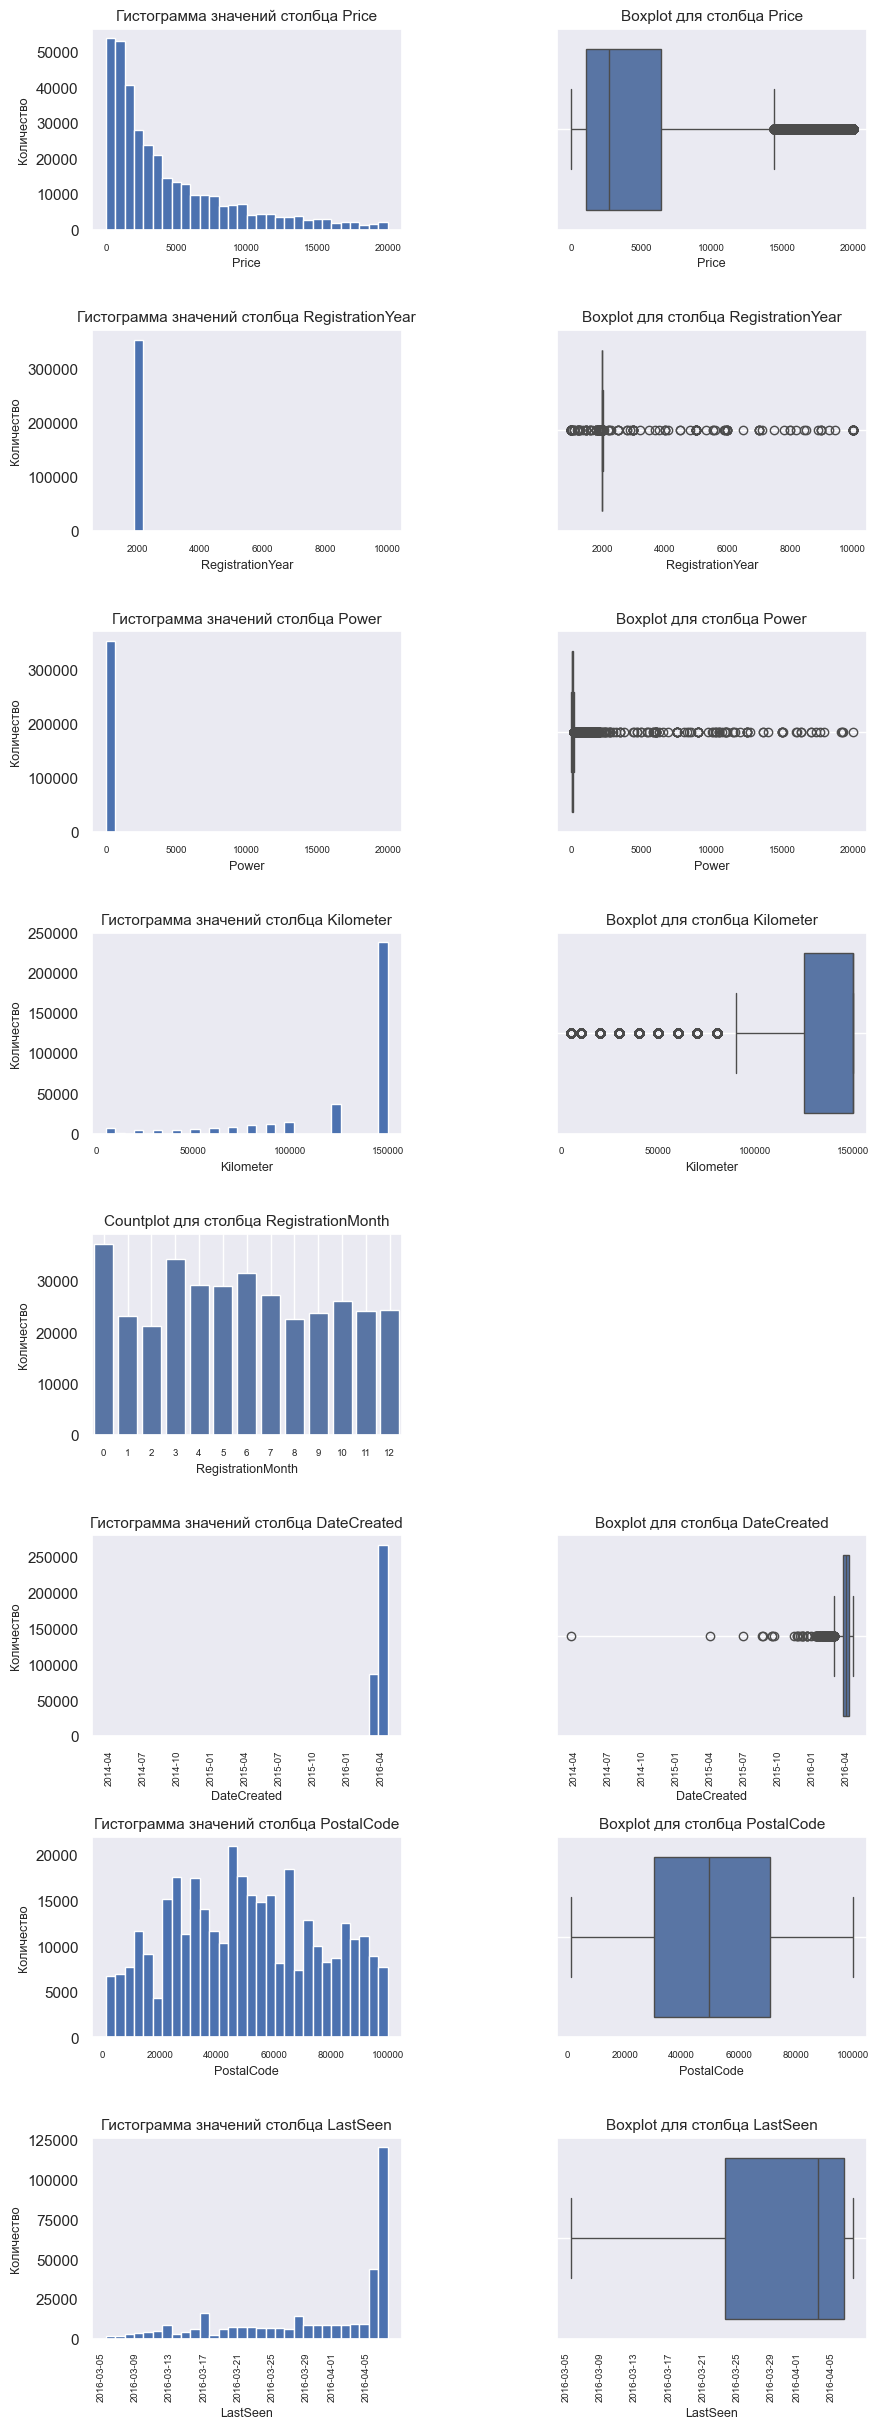

In [24]:
numerical_columns = ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'DateCreated', 'PostalCode', 'LastSeen']
discrete_columns = ['RegistrationMonth']
fig = plt.figure(figsize=(10,30))

for i, column in enumerate(numerical_columns):
    curr_data = data[column]
    if column not in discrete_columns:
        # Гистограмма для непрерывных числовых признаков
        plt.subplot(8, 2, 2*i+1)
        plt.hist(curr_data, bins=30)
        plt.title('Гистограмма значений столбца ' + column, fontsize=11)
        if column in ['DateCreated', 'LastSeen']:
            plt.xticks(rotation=90, ha='right', fontsize=7)
        else:
            plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.ylabel('Количество', fontsize=9)
        plt.grid()
        
        #boxplot для непрерывных числовых признаков
        plt.subplot(8, 2, 2*i+2)
        sns.boxplot(x=curr_data)
        plt.title('Boxplot для столбца ' + column, fontsize=11)
        if column in ['DateCreated', 'LastSeen']:
            plt.xticks(rotation=90, ha='right', fontsize=7)
        else:
            plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.grid()
    else:
        # countplot для дискретных числовых признаков
        plt.subplot(8, 2, 2*i+1)
        sns.countplot(x=curr_data)
        plt.title('Countplot для столбца ' + column, fontsize=11)
        plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.ylabel('Количество', fontsize=9)
        plt.grid()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

#### Визуализация редких значений

`RegistrationYear`

In [25]:
data['RegistrationYear'].quantile(0.001)

1957.0

Фильтруем по годам от 1957 (это квантиль уровня 0.1%) до 2016 года и 4 месяца (самая большая дата регистрации)

Теоретически есть машина 1884 года выпуска, которая все еще на ходу, но подобные примеры только исказят предсказания модели

Количество записей = 19572


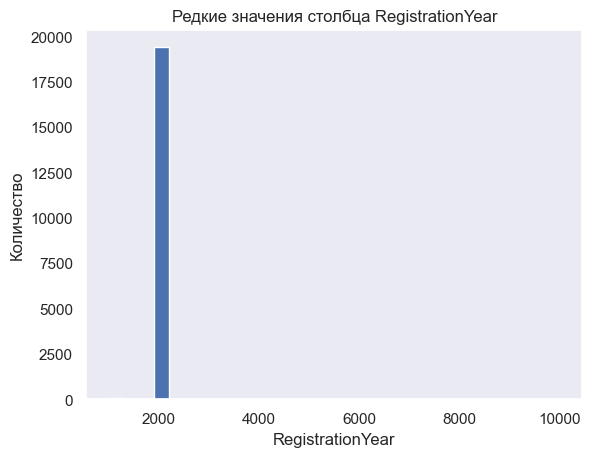

In [26]:
curr_data = data.loc[(data['RegistrationYear'] < 1957) | (data['RegistrationYear'] > 2016) | ((data['RegistrationYear'] == 2016 ) & (data['RegistrationMonth'] > 4)), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['RegistrationYear'], bins=30)
plt.title('Редкие значения столбца ' + 'RegistrationYear')
plt.xlabel('RegistrationYear')
plt.ylabel('Количество')
plt.grid()
plt.show()

Таких записей 19572. Это не мало, но большинство из них некорректна, так что удаляем.

`Power`

0 лошадиных сил

Количество записей = 40225


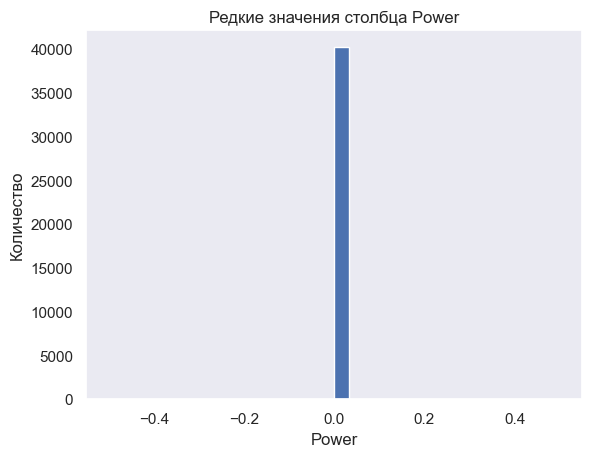

In [27]:
curr_data = data.loc[(data['Power'] == 0), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['Power'], bins=30)
plt.title('Редкие значения столбца ' + 'Power')
plt.xlabel('Power')
plt.ylabel('Количество')
plt.grid()
plt.show()

Равенство нулю мощности означает отсутствие информации о мощности автомобиля. Можно так и оставить

In [28]:
data['Power'].quantile(.999)

700.0

более 700 лошадиных сил (квантиль 99,9% примерно равна 700 л. с.)

Теоретически есть машины с заявленными значениями мощности до 5000, но такие примеры только ухудшат модель

Количество записей = 354


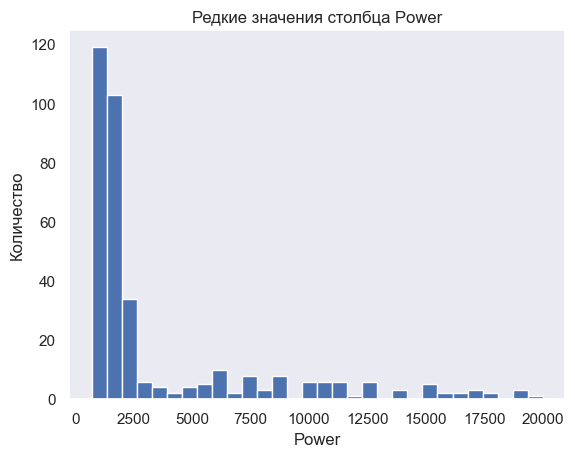

In [29]:
curr_data = data.loc[(data['Power'] > 700), :]
print('Количество записей =', curr_data.shape[0])
plt.hist(curr_data['Power'], bins=30)
plt.title('Редкие значения столбца ' + 'Power')
plt.xlabel('Power')
plt.ylabel('Количество')
plt.grid()
plt.show()

Такие мощности считаем выбросами и их небольшое количество - 354. Так что удалим их

`DateCreated`

In [30]:
data['DateCreated'].quantile(0.001)

Timestamp('2016-02-25 08:44:09.600000')

Удаляем все объявления, созданные раньше квантили

Удаляем

In [31]:
data = data[~((data['RegistrationYear'] < 1957) | (data['RegistrationYear'] > 2016) | ((data['RegistrationYear'] == 2016 ) & (data['RegistrationMonth'] > 4)))]
data = data[data['Power'] <= 700]
data = data[data['DateCreated'] >= pd.Timestamp('2016-02-25 00:00:00')]

Повторно визуализируем распределение числовых столбцов

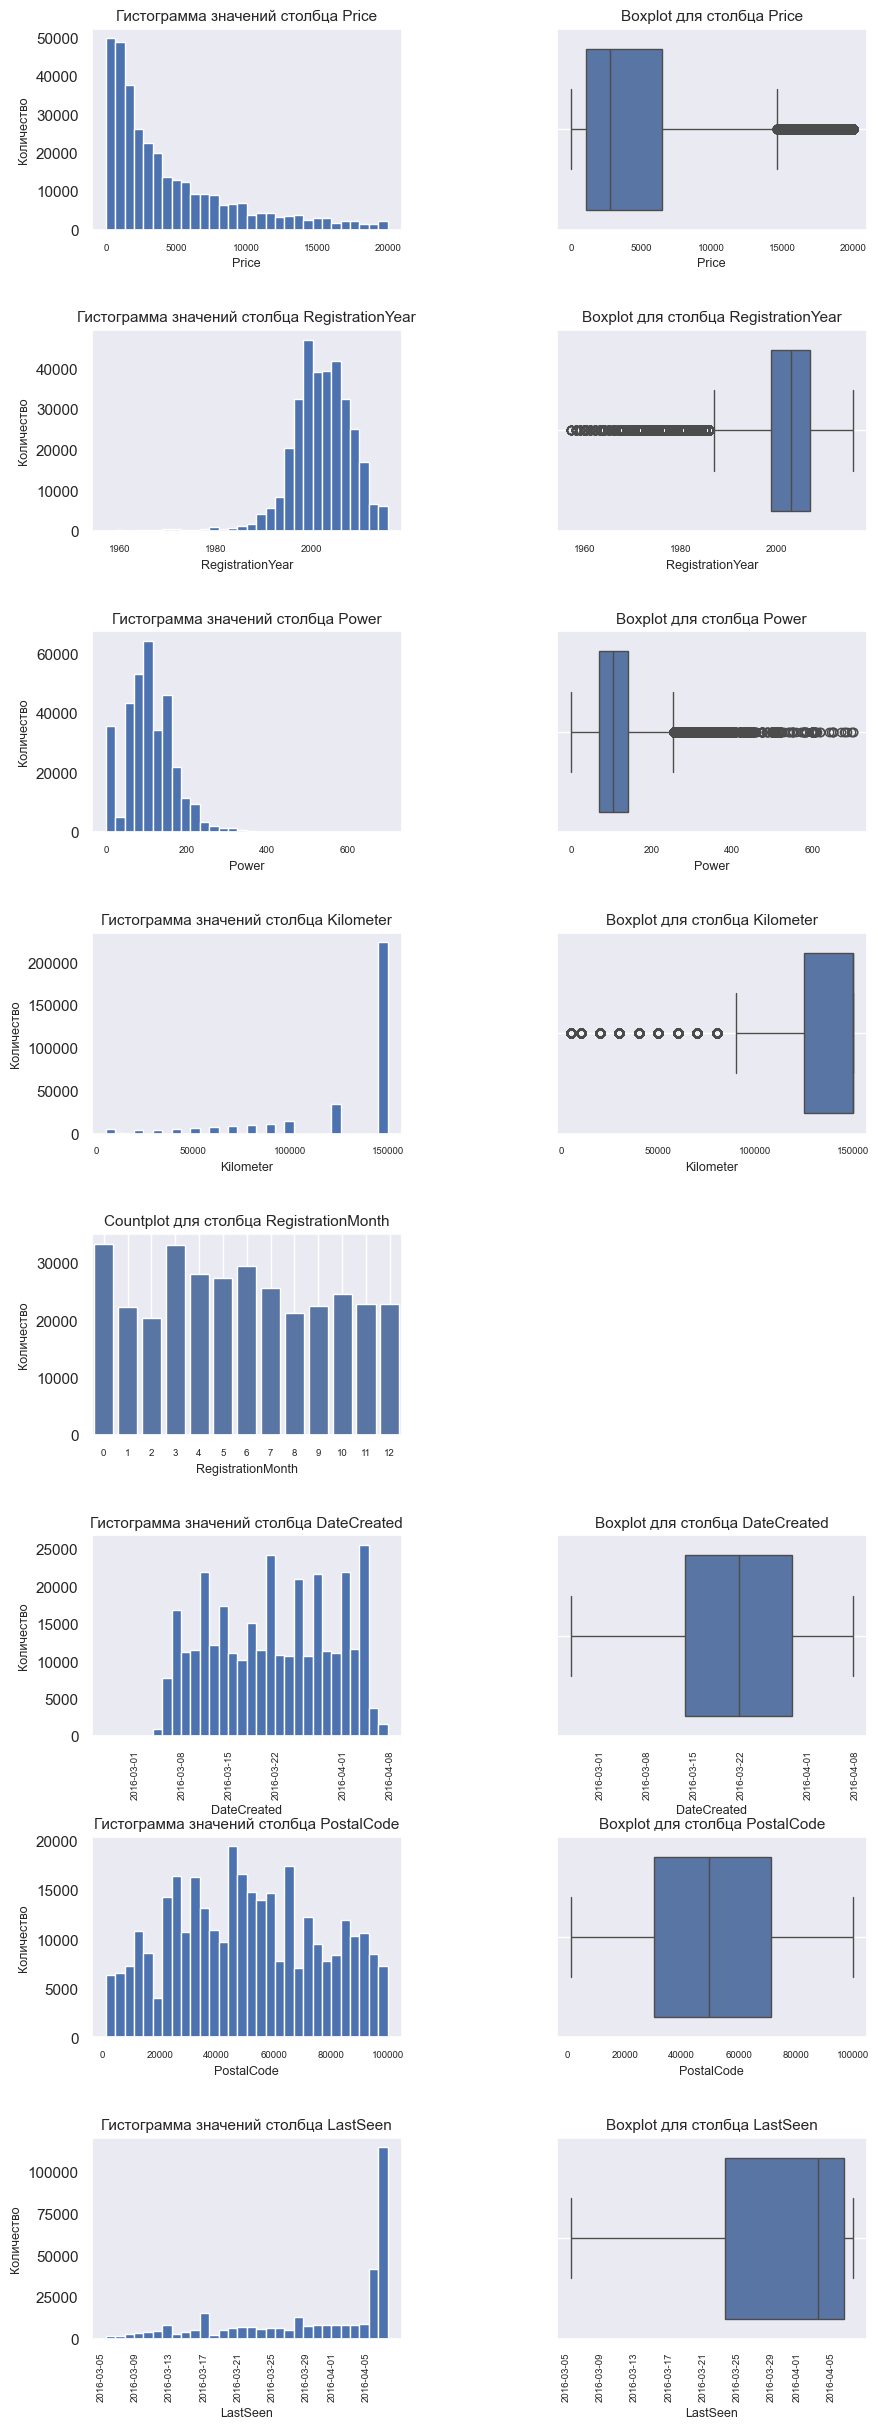

In [32]:
numerical_columns = ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'RegistrationMonth', 'DateCreated', 'PostalCode', 'LastSeen']
discrete_columns = ['RegistrationMonth']
fig = plt.figure(figsize=(10,30))

for i, column in enumerate(numerical_columns):
    curr_data = data[column]
    if column not in discrete_columns:
        # Гистограмма для непрерывных числовых признаков
        plt.subplot(8, 2, 2*i+1)
        plt.hist(curr_data, bins=30)
        plt.title('Гистограмма значений столбца ' + column, fontsize=11)
        if column in ['DateCreated', 'LastSeen']:
            plt.xticks(rotation=90, ha='right', fontsize=7)
        else:
            plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.ylabel('Количество', fontsize=9)
        plt.grid()
        
        #boxplot для непрерывных числовых признаков
        plt.subplot(8, 2, 2*i+2)
        sns.boxplot(x=curr_data)
        plt.title('Boxplot для столбца ' + column, fontsize=11)
        if column in ['DateCreated', 'LastSeen']:
            plt.xticks(rotation=90, ha='right', fontsize=7)
        else:
            plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.grid()
    else:
        # countplot для дискретных числовых признаков
        plt.subplot(8, 2, 2*i+1)
        sns.countplot(x=curr_data)
        plt.title('Countplot для столбца ' + column, fontsize=11)
        plt.xticks(fontsize=7)
        plt.xlabel(column, fontsize=9)
        plt.ylabel('Количество', fontsize=9)
        plt.grid()
plt.subplots_adjust(wspace=0.5, hspace=0.5)
plt.show()

Визулизация распределения качественных признаков

Визуализация столбца `Model`

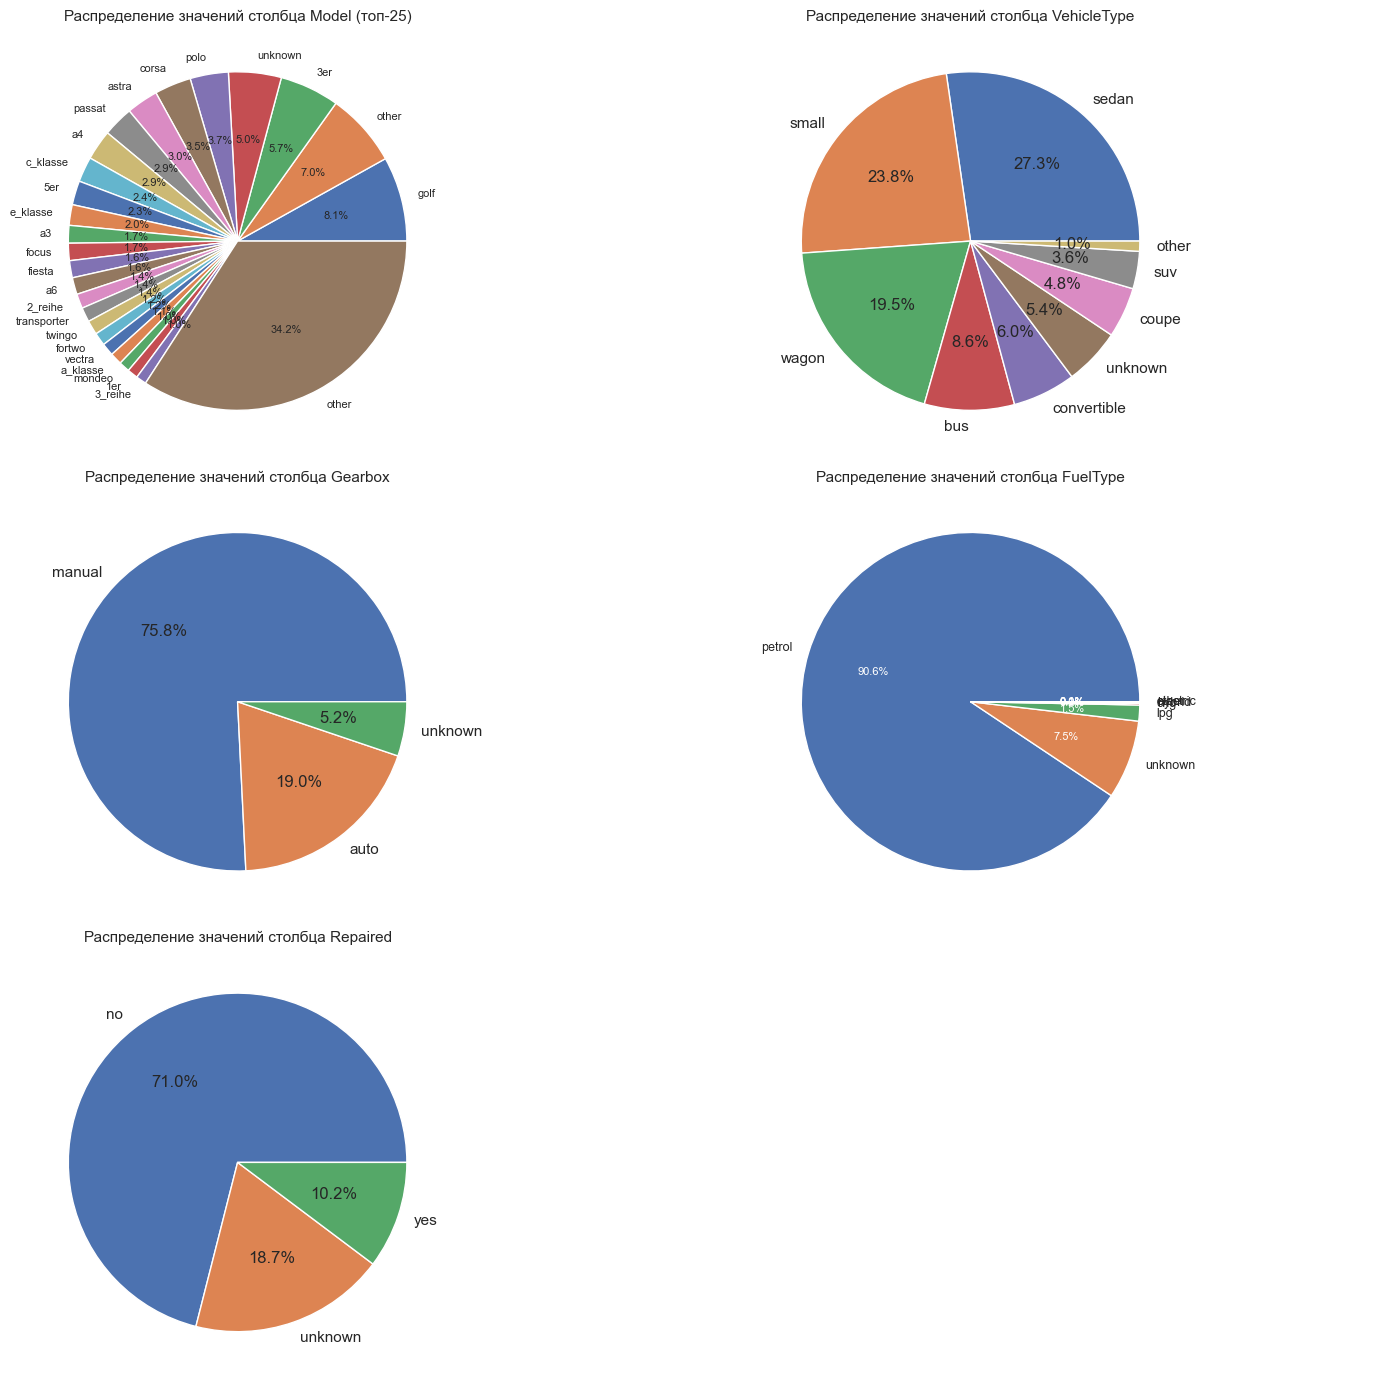

In [33]:
# Визуализация столбца Model
top_models = data['Model'].value_counts().head(25)
other_count = data['Model'].value_counts().iloc[25:].sum()

model_data = pd.concat([
    top_models,
    pd.Series({'other': other_count})
])

fig, axes = plt.subplots(3, 2, figsize=(16, 14))

# Pie chart для Model
axes[0, 0].pie(model_data, autopct='%1.1f%%', labels=model_data.index, textprops={'fontsize': 8})
axes[0, 0].set_title('Распределение значений столбца Model (топ-25)', fontsize=11)

# Pie chart для VehicleType
vehicle_data = data['VehicleType'].value_counts()
axes[0, 1].pie(vehicle_data, autopct='%1.1f%%', labels=vehicle_data.index)
axes[0, 1].set_title('Распределение значений столбца VehicleType', fontsize=11)
axes[0, 1].set_ylabel('')

# Pie chart для Gearbox
gearbox_data = data['Gearbox'].value_counts()
axes[1, 0].pie(gearbox_data, autopct='%1.1f%%', labels=gearbox_data.index)
axes[1, 0].set_title('Распределение значений столбца Gearbox', fontsize=11)
axes[1, 0].set_ylabel('')

# Pie chart для FuelType с исправлением наложения подписей
fuel_data = data['FuelType'].value_counts()
wedges, texts, autotexts = axes[1, 1].pie(fuel_data, autopct='%1.1f%%', labels=fuel_data.index)
axes[1, 1].set_title('Распределение значений столбца FuelType', fontsize=11)
axes[1, 1].set_ylabel('')
# Поворот подписей для лучшей читаемости
for text in texts:
    text.set_fontsize(9)
    text.set_rotation(0)
for autotext in autotexts:
    autotext.set_color('white')
    autotext.set_fontsize(8)

# Pie chart для Repaired
repaired_data = data['Repaired'].value_counts()
axes[2, 0].pie(repaired_data, autopct='%1.1f%%', labels=repaired_data.index)
axes[2, 0].set_title('Распределение значений столбца Repaired', fontsize=11)
axes[2, 0].set_ylabel('')

# Скрыть последний пустой график
axes[2, 1].axis('off')

plt.subplots_adjust(wspace=0.4, hspace=0.4)
plt.tight_layout()
plt.show()

Преобразование даты в число

In [34]:
# Преобразование дат в количество дней (ОДИН РАЗ, ДО разделения на train/test)
base_date = pd.Timestamp("2016-01-01")
data['DateCreated'] = (data['DateCreated'] - base_date).dt.days
data['LastSeen'] = (data['LastSeen'] - base_date).dt.days

# Проверка типов
print("✅ DateCreated dtype:", data['DateCreated'].dtype)
print("✅ LastSeen dtype:", data['LastSeen'].dtype)

✅ DateCreated dtype: int64
✅ LastSeen dtype: int64


#### Удаление неинформативных признаков

* `RegistrationMonth` - месяц регистрации не влияет на цену
* `DateCrawled` - дата скачивани анкеты не может влиять на цену автомобиля
*  `PostalCode` - почтовый индекс не влияет на цену
* `LastSeen` - дата последней активности пользователя не влияет на цену автомобиля
* `NumberOfPictures` - в этом поле всегда 0, но даже если бы в нем была информация, то это бы не влияло на цену.

In [35]:
data.drop(columns=['RegistrationMonth' , 'DateCrawled', 'PostalCode', 'LastSeen', 'NumberOfPictures'], inplace=True)

In [36]:
values_and_type(data)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,Price,int64,0,500,1500,1000,1200
1,VehicleType,object,sedan,small,wagon,bus,convertible
2,RegistrationYear,int64,2000,1999,2005,2001,2006
3,Gearbox,object,manual,auto,unknown,-,-
4,Power,int64,0,75,60,150,101
5,Model,object,golf,other,3er,unknown,polo
6,Kilometer,int64,150000,125000,100000,90000,80000
7,FuelType,object,petrol,unknown,lpg,cng,hybrid
8,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi
9,Repaired,object,no,unknown,yes,-,-


#### Анализ корреляций

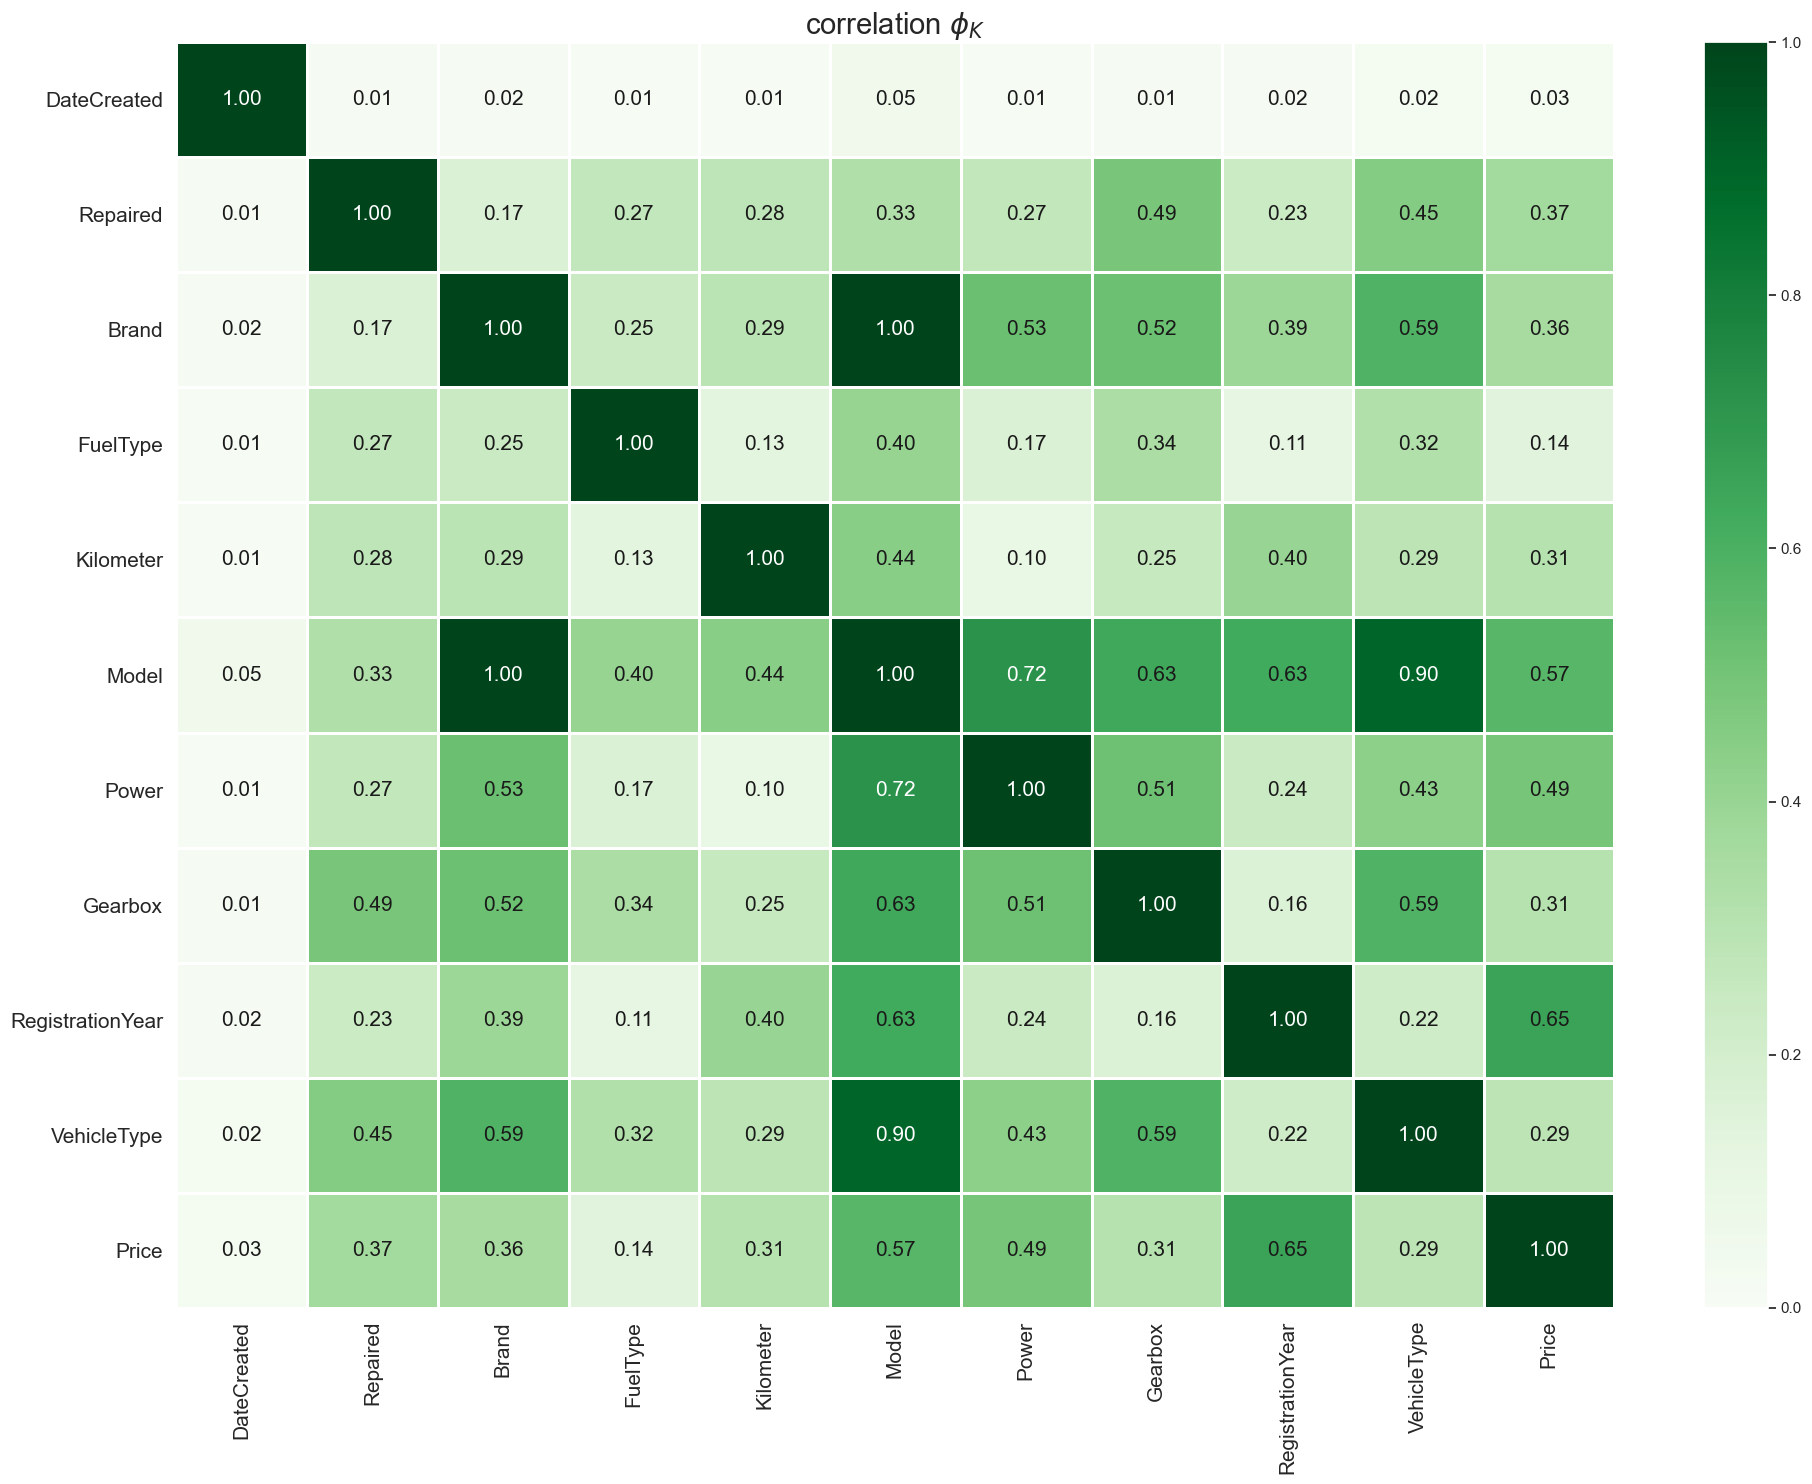

In [37]:
interval_cols = ['Price', 'RegistrationYear', 'Power', 'Kilometer', 'DateCreated']
phik_overview = phik_matrix(data, interval_cols=interval_cols) 

plot_correlation_matrix(
    phik_overview.values,
    x_labels=phik_overview.columns,
    y_labels=phik_overview.index,
    vmin=0, vmax=1, color_map='Greens',
    title=r'correlation $\phi_K$',
    fontsize_factor=1.5,
    figsize=(20, 15)
) 

Имеем очень высокую корреляцию для `Model` и `Brand`, а также для `Model` и `VehicleType`. Для линейной регресии удалим это поле, т. к. оно наимеенее информативное (в нем 250 уникальных значений).

## Обучение моделей

#### Формирование выборок

In [38]:
RANDOM_STATE = 42

Заново загружаем данные

In [39]:
try:
    data = pd.read_csv('./autos.csv')
except:
    data = pd.read_csv('/datasets/autos.csv')

In [40]:
X = data.drop('Price', axis=1)
y = data['Price']
X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=RANDOM_STATE)

Явно указываем категориальные признаки

In [41]:
values_and_type(X_train)

,column_name,type,value_1,value_2,value_3,value_4,value_5
0,DateCrawled,object,2016-03-19 21:49:56,2016-03-11 15:36:59,2016-04-02 14:50:21,2016-03-05 14:44:30,2016-03-22 10:42:10
1,VehicleType,object,sedan,small,wagon,bus,convertible
2,RegistrationYear,int64,2000,1999,2005,2001,2006
3,Gearbox,object,manual,auto,-,-,-
4,Power,int64,0,75,60,150,101
5,Model,object,golf,other,3er,polo,corsa
6,Kilometer,int64,150000,125000,100000,90000,80000
7,RegistrationMonth,int64,0,3,6,5,4
8,FuelType,object,petrol,gasoline,lpg,cng,hybrid
9,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi


Проверка правильности разделения на числовые и категориальные поля

In [42]:
# Обновленные списки без неинформативных полей
categorical_columns = ['VehicleType', 
                       'Gearbox', 
                       'FuelType', 
                       'Model',
                       'Brand', 
                       'Repaired']

numerical_columns = ['RegistrationYear', 
                     'Power', 
                     'Kilometer',
                     'DateCreated']

list_columns = categorical_columns + numerical_columns

dtype_dict = {'VehicleType': 'category', 
                'Gearbox': 'category', 
                'FuelType': 'category', 
                'Model': 'category',
                'Brand': 'category', 
                'Repaired': 'category',
                'RegistrationYear': 'int64', 
                'Power': 'int64', 
                'Kilometer': 'int64',
                'DateCreated': 'int64'}

#Для lgbm
categorical_line = 'name:'
for cat_col in categorical_columns:
    categorical_line += cat_col + ','
categorical_line = categorical_line[:-1]  # Удаляем последнюю запятую
print(categorical_line)

categorical_columns_indexes = [list(X_train.columns).index(cat_col) for cat_col in \
    categorical_columns]
print(X_train.columns)
print(categorical_columns_indexes)
values_and_type(X_train)
for column in X_train.columns:
    if column in categorical_columns:
        print(column, 'cat')
    elif column in numerical_columns:
        print(column, 'num')
    else:
        print(column, 'bad')

name:VehicleType,Gearbox,FuelType,Model,Brand,Repaired
Index(['DateCrawled', 'VehicleType', 'RegistrationYear', 'Gearbox', 'Power',
       'Model', 'Kilometer', 'RegistrationMonth', 'FuelType', 'Brand',
       'Repaired', 'DateCreated', 'NumberOfPictures', 'PostalCode',
       'LastSeen'],
      dtype='object')
[1, 3, 8, 5, 9, 10]


,column_name,type,value_1,value_2,value_3,value_4,value_5
0,DateCrawled,object,2016-03-19 21:49:56,2016-03-11 15:36:59,2016-04-02 14:50:21,2016-03-05 14:44:30,2016-03-22 10:42:10
1,VehicleType,object,sedan,small,wagon,bus,convertible
2,RegistrationYear,int64,2000,1999,2005,2001,2006
3,Gearbox,object,manual,auto,-,-,-
4,Power,int64,0,75,60,150,101
5,Model,object,golf,other,3er,polo,corsa
6,Kilometer,int64,150000,125000,100000,90000,80000
7,RegistrationMonth,int64,0,3,6,5,4
8,FuelType,object,petrol,gasoline,lpg,cng,hybrid
9,Brand,object,volkswagen,opel,bmw,mercedes_benz,audi


DateCrawled bad
VehicleType cat
RegistrationYear num
Gearbox cat
Power num
Model cat
Kilometer num
RegistrationMonth bad
FuelType cat
Brand cat
Repaired cat
DateCreated num
NumberOfPictures bad
PostalCode bad
LastSeen bad


Класс энкодера для замены значения

In [43]:
class ReplaceEncoder(TransformerMixin, BaseEstimator):
    def __init__(self, columns=[], old_value='unknown', new_value='other', columns_to_replace=[]):
        self.columns = columns
        self.old_value = old_value
        self.new_value = new_value
        self.columns_to_replace = columns_to_replace

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            for col in self.columns_to_replace:
                if col not in X.columns:
                    raise ValueError(f"Column {col} not found in data")
        self._is_fitted = True
        return self

    def transform(self, X):
        X_copy = X.copy()
        if isinstance(X, np.ndarray):
            replace_columns_idx = [self.columns.index(column) for column in self.columns_to_replace if column in self.columns]
            for idx in replace_columns_idx:
                X_copy[:, idx] = np.where(X_copy[:, idx] == self.old_value, self.new_value, X_copy[:, idx])
        elif isinstance(X, pd.DataFrame):
            for column in self.columns_to_replace:
                if column in X_copy.columns:
                    X_copy[column] = X_copy[column].replace(self.old_value, self.new_value)
        return X_copy

Класс энкодера для преобразования даты

In [44]:
class FormatDate(TransformerMixin, BaseEstimator):
    def __init__(self, columns=[], base_date=pd.Timestamp("2016-01-01"), columns_to_format=[]):
        self.columns = columns
        self.base_date = base_date
        self.columns_to_format = columns_to_format

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            for col in self.columns_to_format:
                if col not in X.columns:
                    raise ValueError(f"Column {col} not found in data")
        self._is_fitted = True
        return self

    def transform(self, X):
        X_copy = X.copy()
        if isinstance(X, np.ndarray):
            format_columns_idx = [self.columns.index(column) for column in self.columns_to_format if column in self.columns]
            for idx in format_columns_idx:
                X_copy[:, idx] = pd.to_datetime(X_copy[:, idx], format='%Y-%m-%d %H:%M:%S')
                X_copy[:, idx] = (X_copy[:, idx] - self.base_date).dt.days
        elif isinstance(X, pd.DataFrame):
            for column in self.columns_to_format:
                if column in X_copy.columns:
                    X_copy[column] = pd.to_datetime(X_copy[column], format='%Y-%m-%d %H:%M:%S')
                    X_copy[column] = (X_copy[column] - self.base_date).dt.days
        return X_copy

Класс энкодера для удаления полей

In [45]:
class DeleteEncoder(TransformerMixin, BaseEstimator):
    def __init__(self, columns=[], columns_to_delete=[]):
        self.columns = columns
        self.columns_to_delete = columns_to_delete

    def fit(self, X, y=None):
        if isinstance(X, pd.DataFrame):
            for col in self.columns_to_delete:
                if col not in X.columns:
                    raise ValueError(f"Column {col} not found in data")
        self._is_fitted = True
        return self

    def transform(self, X):
        X_copy = X.copy()
        if isinstance(X, np.ndarray):
            delete_columns_idx = [self.columns.index(column) for column in self.columns_to_delete if column in self.columns]
            X_copy = np.delete(X_copy, delete_columns_idx, axis=1)
        elif isinstance(X, pd.DataFrame):
            for column in self.columns_to_delete:
                if column in X_copy.columns:
                    X_copy = X_copy.drop([column], axis=1)
        return X_copy

Класс энкодера для преобразования `np.ndarray` в `pd.DataFrame` с сохранением названий столбцов и индексов

In [46]:
class ToDataFrameEncoder(TransformerMixin, BaseEstimator):
    def __init__(self, columns=None, dtype_dict=None):
        self.columns = columns
        self.dtype_dict = dtype_dict

    def fit(self, X, y=None):
        if isinstance(X, np.ndarray):
            if self.columns is None:
                raise ValueError("Columns must be specified for numpy array input")
            elif len(self.columns) != X.shape[1]:
                raise ValueError("Length of columns must match number of features in X")
            elif len(self.columns) != len(self.dtype_dict):
                raise ValueError("Different number of columns and dtypes")
        self._is_fitted = True
        return self

    def transform(self, X):
        if isinstance(X, np.ndarray):
            return pd.DataFrame(X, columns=self.columns).astype(self.dtype_dict)
        elif isinstance(X, pd.DataFrame):
            return X.astype(self.dtype_dict)
        elif isinstance(X, dict):
            return pd.DataFrame.from_dict(X, orient='index').T.astype(self.dtype_dict)
        else:
            raise ValueError("Unsupported input type for ToDataFrameEncoder")

Класс энкодера для смены типа на `category`

In [47]:
class CategoryTypeEncoder(TransformerMixin, BaseEstimator):
    """Трансформер для приведения категориальных колонок к типу 'category'"""
    def __init__(self, columns=[], columns_to_convert=[]):
        self.columns = columns
        self.columns_to_convert = columns_to_convert

    def fit(self, X, y=None):
        # Проверяем, что колонки существуют
        if isinstance(X, pd.DataFrame):
            for col in self.columns_to_convert:
                if col not in X.columns:
                    raise ValueError(f"Column {col} not found in data")
        self._is_fitted = True
        return self

    def transform(self, X):
        X_copy = X.copy()
        if isinstance(X, np.ndarray):
            convert_columns_idx = [self.columns.index(column) for column in self.columns_to_convert if column in self.columns]
            for idx in convert_columns_idx:
                X_copy[:, idx] = X_copy[:, idx].astype('category')
        elif isinstance(X, pd.DataFrame):
            for column in self.columns:
                if column in X_copy.columns:
                    X_copy[column] = X_copy[column].astype('category')
        return X_copy

In [48]:
all_columns = categorical_columns + numerical_columns

Создаем пайплайн предобработки для линейной регрессии

In [49]:
numeric_pipe_lr = Pipeline([
    ('dateformatter', FormatDate(columns=all_columns, columns_to_format=['DateCreated'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median')),
    ('scaler', StandardScaler())
])

categorical_pipe_lr = Pipeline([
    ('deleter', DeleteEncoder(columns=all_columns, columns_to_delete=['Model'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
    ('replacer', ReplaceEncoder(columns=all_columns, old_value='gasoline', new_value='petrol', columns_to_replace=['FuelType'])),
    ('OHE', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocess_lr = ColumnTransformer(
    [
        ('cat', categorical_pipe_lr, categorical_columns),
        ('num', numeric_pipe_lr, numerical_columns)
    ],
    remainder='drop'
)

И пайплайн предобработки для остальных моделей

In [ ]:
# Пайплайн для деревьев (DecisionTree, RandomForest)
numeric_pipe_tree = Pipeline([
    ('dateformatter', FormatDate(columns=all_columns, columns_to_format=['DateCreated'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median').set_output(transform='pandas'))
])

categorical_pipe_tree = Pipeline([
    ('deleter', DeleteEncoder(columns=all_columns, columns_to_delete=['Model'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
    ('replacer', ReplaceEncoder(columns=all_columns, old_value='gasoline', new_value='petrol', columns_to_replace=['FuelType'])),
    ('OHE', OneHotEncoder(drop='first', handle_unknown='ignore', sparse_output=False))
])

preprocess_tree = ColumnTransformer(
    [
        ('cat', categorical_pipe_tree, categorical_columns),
        ('num', numeric_pipe_tree, numerical_columns)
    ],
    remainder='drop'
)

# Пайплайн для LightGBM - приводим категориальные к типу 'category'
numeric_pipe_lgbm = Pipeline([
    ('dateformatter', FormatDate(columns=all_columns, columns_to_format=['DateCreated'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_pipe_lgbm = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
    ('replacer', ReplaceEncoder(columns=all_columns, old_value='gasoline', new_value='petrol', columns_to_replace=['FuelType']))
])

preprocess_lgbm = Pipeline([
    ('preprocess', ColumnTransformer(
    [
        ('cat', categorical_pipe_lgbm, categorical_columns),
        ('num', numeric_pipe_lgbm, numerical_columns)
    ],
    remainder='drop'
)),
    ('to_df', ToDataFrameEncoder(columns=categorical_columns + numerical_columns, dtype_dict=dtype_dict))
    #('category_type', CategoryTypeEncoder(columns=categorical_columns))
])

# Пайплайн для CatBoost
numeric_pipe_catboost = Pipeline([
    ('dateformatter', FormatDate(columns=all_columns, columns_to_format=['DateCreated'])),
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='median'))
])

categorical_pipe_catboost = Pipeline([
    ('imputer', SimpleImputer(missing_values=np.nan, strategy='constant', fill_value='unknown')),
    ('replacer', ReplaceEncoder(columns=all_columns, old_value='gasoline', new_value='petrol', columns_to_replace=['FuelType']))
])

preprocess_catboost = ColumnTransformer(
    [
        ('cat', categorical_pipe_catboost, categorical_columns),
        ('num', numeric_pipe_catboost, numerical_columns)
    ],
    remainder='drop'
)

Проверка работы пайплайна предобработки для `LightGBM`

In [52]:
test_prep = clone(preprocess_lgbm)
test_prep.fit(X_train)
X_train_prepared = test_prep.transform(X_train)
display(X_train_prepared.head(20))
print(X_train_prepared.dtypes)

,VehicleType,Gearbox,FuelType,Model,Brand,Repaired,RegistrationYear,Power,Kilometer,DateCreated
0,convertible,manual,petrol,eos,volkswagen,no,2008,122,60000,68
1,sedan,manual,petrol,c_klasse,mercedes_benz,no,1999,122,125000,85
2,bus,manual,petrol,5_reihe,peugeot,no,2012,111,50000,73
3,wagon,manual,petrol,a4,audi,no,2009,0,125000,76
4,sedan,auto,petrol,passat,volkswagen,no,2007,200,70000,66
5,wagon,manual,petrol,v70,volvo,no,1997,144,150000,74
6,sedan,manual,petrol,5er,bmw,no,1997,0,150000,79
7,suv,auto,petrol,x_reihe,bmw,no,2009,177,125000,70
8,sedan,manual,unknown,carisma,mitsubishi,yes,1999,0,150000,73
9,unknown,unknown,petrol,other,peugeot,unknown,2016,0,150000,64


VehicleType         category
Gearbox             category
FuelType            category
Model               category
Brand               category
Repaired            category
RegistrationYear       int64
Power                  int64
Kilometer              int64
DateCreated            int64
dtype: object


In [ ]:
# Быстрый тест LightGBM на исходных данных
# Пайплайн будет fit правильно только на тренировочных данных
test_prep = clone(preprocess_lgbm)
pipeline_test = Pipeline([
    ('prep', test_prep),
    ('model', LGBMRegressor(min_data_in_leaf=1, num_leaves=64, verbose=-1, random_state=RANDOM_STATE))
])

pipeline_test.fit(X_train, y_train)
y_pred_test = pipeline_test.predict(X_test)
print('RMSE (быстрый тест):', root_mean_squared_error(y_test, y_pred_test))

[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.003846 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 752
[LightGBM] [Info] Number of data points in the train set: 265776, number of used features: 10
[LightGBM] [Info] Start training from score 4408.063264
[LightGBM] [Warning] min_data_in_leaf is set=1, min_child_samples=20 will be ignored. Current value: min_data_in_leaf=1
RMSE (быстрый тест): 1753.324910386391


Явно задаем список категориальных столбцов

In [54]:
categorical_columns = ['VehicleType', 
                       'Gearbox', 
                       'FuelType', 
                       'Model',
                       'Brand', 
                       'Repaired']
categorical_columns_indexes = [all_columns.index(col) for col in categorical_columns]

Задаем словарь кортежей с названием, моделью и ее параметрами

In [55]:
pipe_parameters = {
    # Линейная регрессия
    "LinearRegression": (
        "LinearRegression",
        Pipeline([
            ('prep', preprocess_lr),
            ('model', LinearRegression(n_jobs=-1))
        ]),
        {}
    ),
    
    # Дерево решений
    "DecisionTree": (
        "DecisionTree",
        Pipeline([
            ('prep', preprocess_tree),
            ('model', DecisionTreeRegressor(
                max_depth=4,
                min_samples_split=3,
                min_samples_leaf=1,
                random_state=RANDOM_STATE
            ))
        ]),
        {
            'model__max_depth': distributions.IntDistribution(2, 12),
            'model__min_samples_split': distributions.IntDistribution(2, 12),
            'model__min_samples_leaf': distributions.IntDistribution(1, 12)
        }
    ),
    
    # Случайный лес
    "RandomForest": (
        "RandomForest",
        Pipeline([
            ('prep', preprocess_tree),
            ('model', RandomForestRegressor(
                n_estimators=500,
                max_depth=3,
                min_samples_split=2,
                min_samples_leaf=1,
                random_state=RANDOM_STATE,
                n_jobs=-1
            ))
        ]),
        {
            'model__n_estimators': distributions.IntDistribution(100, 500, step=50),
            'model__max_depth': distributions.IntDistribution(2, 12),
            'model__min_samples_split': distributions.IntDistribution(2, 12),
            'model__min_samples_leaf': distributions.IntDistribution(1, 12)
        }
    ),
    
    # LightGBM
    "LightGBM": (
        "LightGBM",
        Pipeline([
            ('prep', preprocess_lgbm),
            ('model', LGBMRegressor(
                num_leaves=31,
                max_depth=-1,
                learning_rate=0.1,
                n_estimators=400,
                n_jobs=-1,
                categorical_feature=categorical_columns,
                verbose=-1
            ))
        ]),
        {
            'model__num_leaves': distributions.IntDistribution(10, 60),
            'model__max_depth': distributions.IntDistribution(3, 12),
            'model__learning_rate': distributions.FloatDistribution(0.02, 0.2, log=True),
            'model__min_child_samples': distributions.IntDistribution(20, 100)
        }
    ),
    
    # CatBoost
    "CatBoost": (
        "CatBoost",
        Pipeline([
            ('prep', preprocess_catboost),
            ('model', CatBoostRegressor(
                iterations=400,
                random_seed=RANDOM_STATE,
                verbose=False,
                task_type='GPU',
                devices='0',
                cat_features=categorical_columns_indexes
            ))
        ]),
        {
            'model__learning_rate': distributions.FloatDistribution(0.02, 0.2, log=True),
            'model__depth': distributions.IntDistribution(3, 12),
            'model__l2_leaf_reg': distributions.FloatDistribution(1, 50, log=True),
            'model__bagging_temperature': distributions.FloatDistribution(0, 1),
            'model__random_strength': distributions.FloatDistribution(0, 2)
        }
    )
}

Создаем кастомную функцию `objective` для `optuna`

In [56]:
def objective_with_timing(trial, params_dist, pipeline, X, y, cv_folds=3):
    """
    Objective function для Optuna.
    Возвращает RMSE и сохраняет время обучения.
    """
    # Выгружаем параметры из распределений
    params = {}
    for param_name, distribution in params_dist.items():
        if isinstance(distribution, distributions.FloatDistribution):
            params[param_name] = trial.suggest_float(
                param_name,
                distribution.low,
                distribution.high,
                log=distribution.log
            )
        elif isinstance(distribution, distributions.IntDistribution):
            params[param_name] = trial.suggest_int(
                param_name,
                distribution.low,
                distribution.high,
                step=getattr(distribution, 'step', 1)
            )
    
    # Клонируем и обновляем пайплайн
    current_pipeline = clone(pipeline)
    current_pipeline.set_params(**params)
    
    #'''
    # Определяем categorical_feature для LightGBM
    # (если в данных есть столбцы с типом 'category')
    fit_params = {}
    if isinstance(X, pd.DataFrame):
        categorical_features = [col for col in X.columns if X[col].dtype.name == 'category']
        if categorical_features:
            # Только для LightGBM
            model = current_pipeline.named_steps['model']
            if 'LGBM' in model.__class__.__name__:
                fit_params['model__categorical_feature'] = categorical_columns
    #'''
    
    # Кросс-валидация с замером времени
    start_train = time.time()
    
    cv_results = cross_validate(
        current_pipeline, X, y,
        cv=cv_folds,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        },
        params=fit_params,
        n_jobs=1
    )
    
    cv_time = time.time() - start_train
    
    # Метрики
    rmse = -cv_results['test_rmse'].mean()
    mae = -cv_results['test_mae'].mean()
    r2 = cv_results['test_r2'].mean()
    
    # Сохраняем в user_attrs
    trial.set_user_attr('cv_time', cv_time)
    trial.set_user_attr('rmse', rmse)
    trial.set_user_attr('mae', mae)
    trial.set_user_attr('r2', r2)
    
    return rmse

Задаем имена моделей, функций и вычислений для цикла далее

In [57]:
objectives_names = ["lr_objective", 
                    "dt_objective",
                    "rf_objective",
                    "lgbm_objective",
                    "catboost_objective"]

studies_names = ["lr_study", 
                "dt_study",
                "rf_study",
                "lgbm_study",
                "catboost_study"]

model_names = ["LinearRegression",
                "DecisionTree",
                "RandomForest",
                "LightGBM",
                "CatBoost"]

Поиск лучших наборов гиперпараметров моделей на кросс-валидации

In [58]:
model_names = ["LinearRegression", "DecisionTree", "RandomForest", "LightGBM", "CatBoost"]
#model_names = ["LightGBM"]  # CatBoost has cat_features config issues in cross_validate
results = {}

for model_name in model_names:
    print(f"\n{'='*60}")
    print(f"  ОПТИМИЗАЦИЯ: {model_name}")
    print(f"{'='*60}")
    
    _, pipeline, params_dist = pipe_parameters[model_name]
    
    # Если нет параметров для оптимизации (LinearRegression)
    if not params_dist:
        print("   Нет параметров для оптимизации")

        start = time.time()
        cv_results = cross_validate(
        pipeline, X_train, y_train,
        cv=3,
        scoring={
            'rmse': 'neg_root_mean_squared_error',
            'mae': 'neg_mean_absolute_error',
            'r2': 'r2'
        },
        n_jobs=1
        )
        cv_time = time.time() - start
        
        rmse_cv = -cv_results['test_rmse'].mean()
        mae_cv = -cv_results['test_mae'].mean()
        r2_cv = cv_results['test_r2'].mean()
        
        results[model_name] = {
            'rmse cv': rmse_cv,
            'mae cv': mae_cv,
            'r2 cv': r2_cv,
            'cv time': cv_time,
            'n trials': 1
        }
        
        print(f"   RMSE: {rmse_cv:.2f} | MAE: {mae_cv:.2f} | R²: {r2_cv:.4f}")
        
        
        
    else:
        # Создаем Study
        study = optuna.create_study(direction='minimize')
        
        # Objective function с параметрами
        objective_func = partial(
            objective_with_timing,
            params_dist=params_dist,
            pipeline=pipeline,
            X=X_train,
            y=y_train,
            cv_folds=3
        )
        
        # Оптимизируем
        study.optimize(objective_func, n_trials=15, show_progress_bar=False)
        
        # Лучший trial
        best_trial = study.best_trial
        
        results[model_name] = {
            'rmse cv': best_trial.value,
            'mae cv': best_trial.user_attrs['mae'],
            'r2 cv': best_trial.user_attrs['r2'],
            'cv time': best_trial.user_attrs['cv_time'],
            'params': best_trial.params,
            'n trials': len(study.trials)
        }
        
        print(f"   RMSE: {best_trial.value:.2f} | MAE: {best_trial.user_attrs['mae']:.2f} | R²: {best_trial.user_attrs['r2']:.4f}")
        print(f"\n   Лучшие параметры:")
        for key, val in best_trial.params.items():
            print(f"     {key}: {val}")

print(f"\n{'='*60}")
print("ИТОГОВОЕ СРАВНЕНИЕ")
print(f"{'='*60}")

results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('rmse cv')
print(results_df[['rmse cv', 'mae cv', 'r2 cv', 'cv time']])


  ОПТИМИЗАЦИЯ: LinearRegression
   Нет параметров для оптимизации


[I 2026-03-22 18:17:34,246] A new study created in memory with name: no-name-9274255a-1db6-48c3-be43-4cbe2359b7b7


   RMSE: 3468.65 | MAE: 2554.90 | R²: 0.4073

  ОПТИМИЗАЦИЯ: DecisionTree


[I 2026-03-22 18:17:36,806] Trial 0 finished with value: 2747.0655612221294 and parameters: {'model__max_depth': 4, 'model__min_samples_split': 12, 'model__min_samples_leaf': 4}. Best is trial 0 with value: 2747.0655612221294.
[I 2026-03-22 18:17:39,626] Trial 1 finished with value: 2425.3021329459416 and parameters: {'model__max_depth': 6, 'model__min_samples_split': 7, 'model__min_samples_leaf': 11}. Best is trial 1 with value: 2425.3021329459416.
[I 2026-03-22 18:17:43,065] Trial 2 finished with value: 2117.712565852542 and parameters: {'model__max_depth': 11, 'model__min_samples_split': 8, 'model__min_samples_leaf': 2}. Best is trial 2 with value: 2117.712565852542.
[I 2026-03-22 18:17:46,412] Trial 3 finished with value: 2154.6385810851075 and parameters: {'model__max_depth': 10, 'model__min_samples_split': 8, 'model__min_samples_leaf': 3}. Best is trial 2 with value: 2117.712565852542.
[I 2026-03-22 18:17:49,322] Trial 4 finished with value: 2324.722579693436 and parameters: {'mo

   RMSE: 2078.90 | MAE: 1300.41 | R²: 0.7871

   Лучшие параметры:
     model__max_depth: 12
     model__min_samples_split: 4
     model__min_samples_leaf: 5

  ОПТИМИЗАЦИЯ: RandomForest


...

   RMSE: 1961.10 | MAE: 1232.02 | R²: 0.8105

   Лучшие параметры:
     model__n_estimators: 500
     model__max_depth: 12
     model__min_samples_split: 9
     model__min_samples_leaf: 4

  ОПТИМИЗАЦИЯ: LightGBM


[I 2026-03-22 18:39:12,460] Trial 0 finished with value: 1744.6814085959024 and parameters: {'model__num_leaves': 60, 'model__max_depth': 7, 'model__learning_rate': 0.08715437212615024, 'model__min_child_samples': 79}. Best is trial 0 with value: 1744.6814085959024.
[I 2026-03-22 18:39:15,058] Trial 1 finished with value: 1777.16652530755 and parameters: {'model__num_leaves': 47, 'model__max_depth': 4, 'model__learning_rate': 0.17227496391215416, 'model__min_child_samples': 54}. Best is trial 0 with value: 1744.6814085959024.
[I 2026-03-22 18:39:17,609] Trial 2 finished with value: 1780.0687347540072 and parameters: {'model__num_leaves': 18, 'model__max_depth': 4, 'model__learning_rate': 0.17586354520783543, 'model__min_child_samples': 95}. Best is trial 0 with value: 1744.6814085959024.
[I 2026-03-22 18:39:20,837] Trial 3 finished with value: 1754.5889315961958 and parameters: {'model__num_leaves': 27, 'model__max_depth': 10, 'model__learning_rate': 0.08244019961422587, 'model__min_ch

   RMSE: 1736.97 | MAE: 1051.01 | R²: 0.8514

   Лучшие параметры:
     model__num_leaves: 40
     model__max_depth: 9
     model__learning_rate: 0.12778620982441544
     model__min_child_samples: 65

  ОПТИМИЗАЦИЯ: CatBoost


[I 2026-03-22 18:41:01,521] Trial 0 finished with value: 1770.0625080747914 and parameters: {'model__learning_rate': 0.0543103582299049, 'model__depth': 11, 'model__l2_leaf_reg': 4.610580554232711, 'model__bagging_temperature': 0.09259440563544452, 'model__random_strength': 1.3949529799829754}. Best is trial 0 with value: 1770.0625080747914.
[I 2026-03-22 18:41:47,146] Trial 1 finished with value: 1809.6533879013684 and parameters: {'model__learning_rate': 0.03742142227880505, 'model__depth': 10, 'model__l2_leaf_reg': 11.698564137336833, 'model__bagging_temperature': 0.20898662795055778, 'model__random_strength': 1.5762844050450866}. Best is trial 0 with value: 1770.0625080747914.
[I 2026-03-22 18:42:19,408] Trial 2 finished with value: 1761.9920618844892 and parameters: {'model__learning_rate': 0.16977104922269273, 'model__depth': 8, 'model__l2_leaf_reg': 2.2140558521125726, 'model__bagging_temperature': 0.32775396880077423, 'model__random_strength': 0.2682432010381952}. Best is trial

   RMSE: 1761.99 | MAE: 1071.98 | R²: 0.8470

   Лучшие параметры:
     model__learning_rate: 0.16977104922269273
     model__depth: 8
     model__l2_leaf_reg: 2.2140558521125726
     model__bagging_temperature: 0.32775396880077423
     model__random_strength: 0.2682432010381952

ИТОГОВОЕ СРАВНЕНИЕ
                      rmse cv       mae cv     r2 cv     cv time
LightGBM          1736.965202  1051.006506  0.851359    3.600933
CatBoost          1761.992062   1071.98204  0.847042   32.260196
RandomForest      1961.096009   1232.02469  0.810534  135.486568
DecisionTree      2078.903882  1300.410133   0.78709    3.420592
LinearRegression  3468.648323  2554.895892  0.407344       1.929


  ИТОГОВОЕ СРАВНЕНИЕ

| Модель              |    rmse cv |     mae cv |    r2 cv |   cv time |
|---------------------|-----------:|-----------:|---------:|----------:|
| LightGBM            | 1736.965202 | 1051.006506 | 0.851359 |  3.600933 |
| CatBoost            | 1761.992062 | 1071.982040 | 0.847042 | 32.260196 |
| RandomForest        | 1961.096009 | 1232.024690 | 0.810534 | 135.486568 |
| DecisionTree        | 2078.903882 | 1300.410133 | 0.787090 |  3.420592 |
| LinearRegression    | 3468.648323 | 2554.895892 | 0.407344 |  1.929000 |

МОДЕЛИ С ЛУЧШИМИ ПАРАМЕТРАМИ

`LinearRegression`

RMSE: 3468.65 | MAE: 2554.90 | R²: 0.4073

Нет параметров

`DecisionTree`

RMSE: 2078.90 | MAE: 1300.41 | R²: 0.7871

Лучшие параметры:
* model__max_depth: 12
* model__min_samples_split: 4
* model__min_samples_leaf: 5

`RandomForest`

RMSE: 1961.10 | MAE: 1232.02 | R²: 0.8105

Лучшие параметры:
* model__n_estimators: 500
* model__max_depth: 12
* model__min_samples_split: 9
* model__min_samples_leaf: 4

`LightGBM`

RMSE: 1736.97 | MAE: 1051.01 | R²: 0.8514

Лучшие параметры:
* model__num_leaves: 40
* model__max_depth: 9
* model__learning_rate: 0.12778620982441544
* model__min_child_samples: 65

`CatBoost`

RMSE: 1761.99 | MAE: 1071.98 | R²: 0.8470

Лучшие параметры:
* model__learning_rate: 0.16977104922269273
* model__depth: 8
* model__l2_leaf_reg: 2.2140558521125726
* model__bagging_temperature: 0.32775396880077423
* model__random_strength: 0.2682432010381952

### Обучение лучшей модели и предсказание на тестовой выборке

Лучшей моделью по `Значению метрики RMSE`, `Времени обучения на кросс-валидации` оказалась `LigthGBM` с параметрами
* model__num_leaves: 40
* model__max_depth: 9
* model__learning_rate: 0.12778620982441544
* model__min_child_samples: 65

In [62]:
best_model_name = results_df.index[0]
best_pipeline = pipe_parameters[best_model_name][1]
best_pipeline.set_params(**results[best_model_name]['params'])

start = time.time()
best_pipeline.fit(X_train, y_train)
train_time = time.time() - start

start = time.time()
y_pred = best_pipeline.predict(X_test)
test_time = time.time() - start

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

results[best_model_name]['Train time'] = train_time
results[best_model_name]['Test time'] = test_time
results[best_model_name]['rmse test'] = rmse
results[best_model_name]['mae test'] = mae
results[best_model_name]['r2 test'] = r2
    
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('rmse cv')
print('ИТОГОВЫЕ РЕЗУЛЬТАТЫ')
print('Лучшей оказалась модель:', best_model_name)
print('Лучшие параметры модели:')
display(results[best_model_name]['params'])
dict_to_display = {
    'Качество на кросс-валидации': results[best_model_name]['rmse cv'],
    'Время обучения на кросс-валидации': results[best_model_name]['cv time'],
    'Время обучения на всем train': results[best_model_name]['Train time'],
    'Время предсказания на тесте': results[best_model_name]['Test time'],
    'RMSE на тесте': results[best_model_name]['rmse test']
}
df_to_display = pd.DataFrame.from_dict(dict_to_display, orient='index', columns=['Значение'])
display(df_to_display.T)

ИТОГОВЫЕ РЕЗУЛЬТАТЫ
Лучшей оказалась модель: LightGBM
Лучшие параметры модели:


{'model__num_leaves': 40,
 'model__max_depth': 9,
 'model__learning_rate': 0.12778620982441544,
 'model__min_child_samples': 65}

,Качество на кросс-валидации,Время обучения на кросс-валидации,Время обучения на всем train,Время предсказания на тесте,RMSE на тесте
Значение,1736.965202,3.600933,1.417385,0.233593,1717.857391


| Модель    |   Качество на кросс-валидации |   Время обучения на кросс-валидации |   Время обучения на всем train |   Время предсказания на тесте |   RMSE на тесте |
|-----------|-------------------------------|-------------------------------------|--------------------------------|-------------------------------|-----------------|
| LightGBM  |                     1736.965202 |                            3.600933 |                       1.417385 |                      0.233593 |       1717.857391 |

## Анализ моделей

Требовалось выбрать модель, которая будет оптимальной по следующим критериям:
* качество предсказания
* время обучения модели
* время предсказания модели

Были проанализированы следующие модели:
* Линейная регрессия
* Дерево решений
* Случайный лес
* Градиентный бустинг (CatBoost и LightGBM)

Для обучения модели и дальнейшего предсказания стоимость машин использовались данные из файла `autos.csv`.

Для загруженных данных были выполнены следующие шаги предобработки:
* Пропуски в категориальных столбцах (например, в столбце `Модель`) были заполнены значением `unknown`.
* Были удалены явные дубликаты в данных, таких строк было 4.
* Был найден неявный дубликат в столбце `FuelType`: `petrol` и `gasoline` это названия одного и того же топлива в разных странах. Во всех записях.`gasoline` был заменен на `petrol`.
* Перед обучением модели были удалены неинформативные колонки: `DateCrawled`, `RegistrationMonth`, `NumberOfPictures`, `PostalCode`, `LastSeen`.
* Информация о дате была переведена в числовой формат.

Для выбранных 5 типов моделей был произведен отбор гиперпараметров, минимизируя метрику `RMSE` на кросс-валидации. 

Лучшей моделью оказалась `LightGBM`, которая показала следующие значения целевой метрики и времени обучения/предсказания

| Модель    |   Качество на кросс-валидации |   Время обучения на кросс-валидации |   Время обучения на всем train |   Время предсказания на тесте |   RMSE на тесте |
|-----------|-------------------------------|-------------------------------------|--------------------------------|-------------------------------|-----------------|
| LightGBM  |                     1736.965202 |                            3.600933 |                       1.417385 |                      0.233593 |       1717.857391 |

Именно эту модель и рекомендуется использовать для предсказания цены на автомобили на реальных данных